# Task 1: Basic DQN for SpaceRace

All real logic lives in the`spacerace_dqn` package under `Assignment2/src/`. This notebook:

1. Loads or runs baselines.
2. Loads or trains the basic DQN.
3. Evaluates the trained agent across all difficulties.
4. Renders the agent playing one episode (inline GIF).
5. Packages the Codabench submission and verifies the ZIP.

Set `RUN_TRAINING = True` to train

In [ ]:
from __future__ import annotations

import json
import sys
from pathlib import Path

# locate the assignment directory by searching upwards from the notebook cwd
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / 'Assignment2' / 'src' / 'spacerace_dqn').exists():
        ASSIGNMENT_DIR = candidate / 'Assignment2'
        break
else:
    raise RuntimeError('Could not locate Assignment2/src/spacerace_dqn from notebook cwd.')

sys.path.insert(0, str(ASSIGNMENT_DIR / 'src'))
DOCS_DIR = ASSIGNMENT_DIR / 'docs'
SUBMISSIONS_DIR = ASSIGNMENT_DIR / 'submissions'

from src.spacerace_dqn import (
    Config,
    DQNTrainer,
    Evaluator,
    SubmissionPackager,
    GifRecorder,
    DQNInferencePolicy,
    RandomPolicy,
    AlwaysUpPolicy,
    RGBHeuristicPolicy,
    SemanticHeuristicPolicy,
    plot_baselines,
    plot_training,
    DEVICE,
)

RUN_TRAINING = False  # True to retrain from scratch
RUN_BASELINES = True 
RECORD_GIF = True  # render one DQN episode as a GIF

cfg = Config()
print(f'device={DEVICE}')
print(f'submission_name={cfg.submission_name}')
print(f'episodes={cfg.episodes}, eval_every={cfg.eval_every}, frame_stack={cfg.frame_stack}')

device=cpu
submission_name=task1_basic_dqn
episodes=120, eval_every=10, frame_stack=1


## Baselines

Four reference policies on difficulty 0 (10 episodes, seeds 2026..2035):

- `RandomPolicy` — sanity check (sub/down uniformly random).
- `AlwaysUpPolicy` — naive baseline (always action 0).
- `RGBHeuristicPolicy` — Codabench-legal heuristic; reads only the RGB frame.
- `SemanticHeuristicPolicy` — same logic but reads `info['semantic_obs']`. Sanity check the RGB extractor.

In [10]:
evaluator = Evaluator(cfg)
if RUN_BASELINES:
    baselines = [
        evaluator.run(p, n_episodes=cfg.baseline_episodes)
        for p in (RandomPolicy(), AlwaysUpPolicy(),
                  RGBHeuristicPolicy(), SemanticHeuristicPolicy())
    ]
    DOCS_DIR.mkdir(parents=True, exist_ok=True)
    (DOCS_DIR / 'task1_baselines.json').write_text(
        json.dumps(baselines, indent=2), encoding='utf-8')
else:
    baselines = json.loads((DOCS_DIR / 'task1_baselines.json').read_text(encoding='utf-8'))

print(f"{'policy':<22}{'mean':>8}{'std':>8}{'collisions':>14}")
for b in baselines:
    print(f"{b['policy']:<22}{b['mean_score']:>8.2f}{b['std_score']:>8.2f}{b['mean_collisions']:>14.1f}")

policy                    mean     std    collisions
random                    0.20    0.40          19.0
always_up                17.00    0.00          16.0
rgb_heuristic            17.00    0.00           3.0
semantic_heuristic       17.00    0.00           3.0


## Train the basic DQN

`DQNTrainer` runs the loop, evaluates every `eval_every` episodes, and keeps
the per-episode history

In [11]:
if RUN_TRAINING:
    trainer = DQNTrainer(cfg)
    agent = trainer.train()
    final_eval = trainer.final_eval()
    history = trainer.history
    eval_history = trainer.eval_history
    train_minutes = trainer.train_minutes
    state_shape = trainer.state_shape
    print(f'Training finished in {train_minutes:.1f} min.')
else:
    summary_path = SUBMISSIONS_DIR / cfg.submission_name / 'summary.json'
    history_path = SUBMISSIONS_DIR / cfg.submission_name / 'history.json'
    summary = json.loads(summary_path.read_text(encoding='utf-8'))
    history_payload = json.loads(history_path.read_text(encoding='utf-8'))
    history = history_payload['train']
    eval_history = history_payload['eval']
    final_eval = summary['final_eval']
    train_minutes = summary['train_minutes']
    state_shape = (3 * cfg.frame_stack, 54, 39)
    agent = None
    print(f'Loaded existing run: {summary_path}')

print(f"final mean_score={final_eval['mean_score']:.2f} "
      f"std={final_eval['std_score']:.2f} mean_max_q={final_eval['mean_max_q']:.3f}")
print(f"score/training-min={final_eval['mean_score']/max(train_minutes, 1e-9):.2f} "
      f"q/training-min={final_eval['mean_max_q']/max(train_minutes, 1e-9):.2f}")

Loaded existing run: c:\Projects\DeepLearning\Assignment2\submissions\task1_basic_dqn\summary.json
final mean_score=24.00 std=0.00 mean_max_q=4.547
score/training-min=4.15 q/training-min=0.79


## Training curves and baseline comparison

`plot_training` writes a 4-panel PNG (score / loss / Q / ε) and `plot_baselines`
writes a bar chart of every static policy plus the DQN

c:\Projects\DeepLearning\Assignment2\submissions\task1_basic_dqn\training_curves.png
c:\Projects\DeepLearning\Assignment2\submissions\task1_basic_dqn\baselines_vs_dqn.png


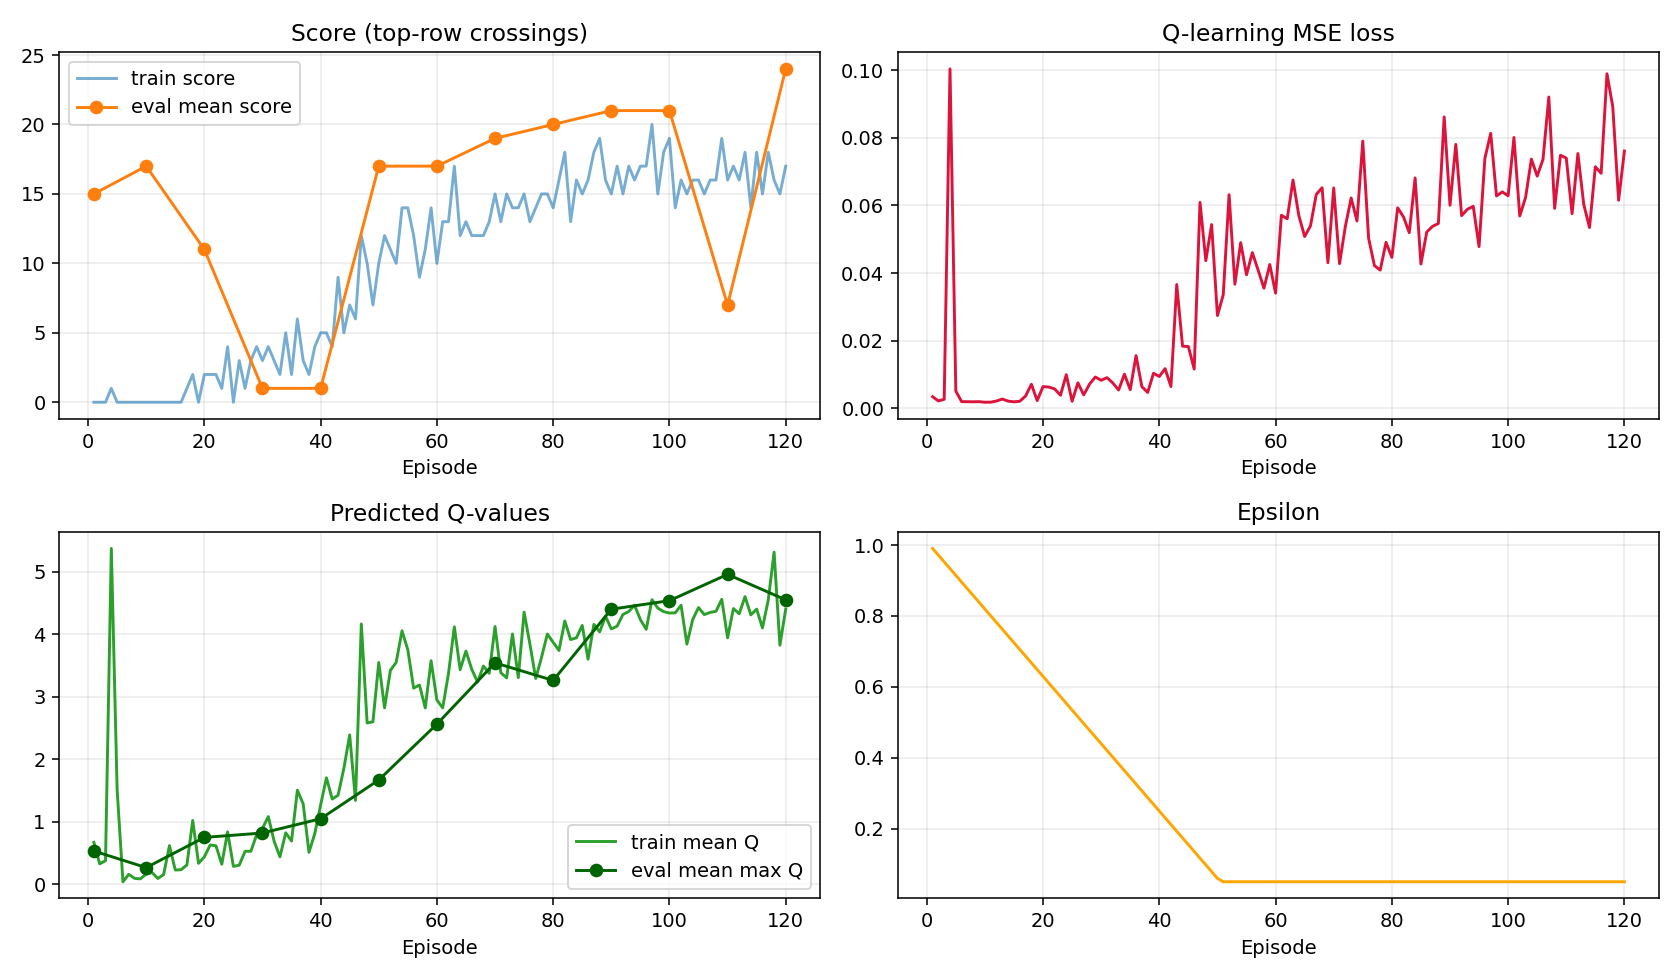

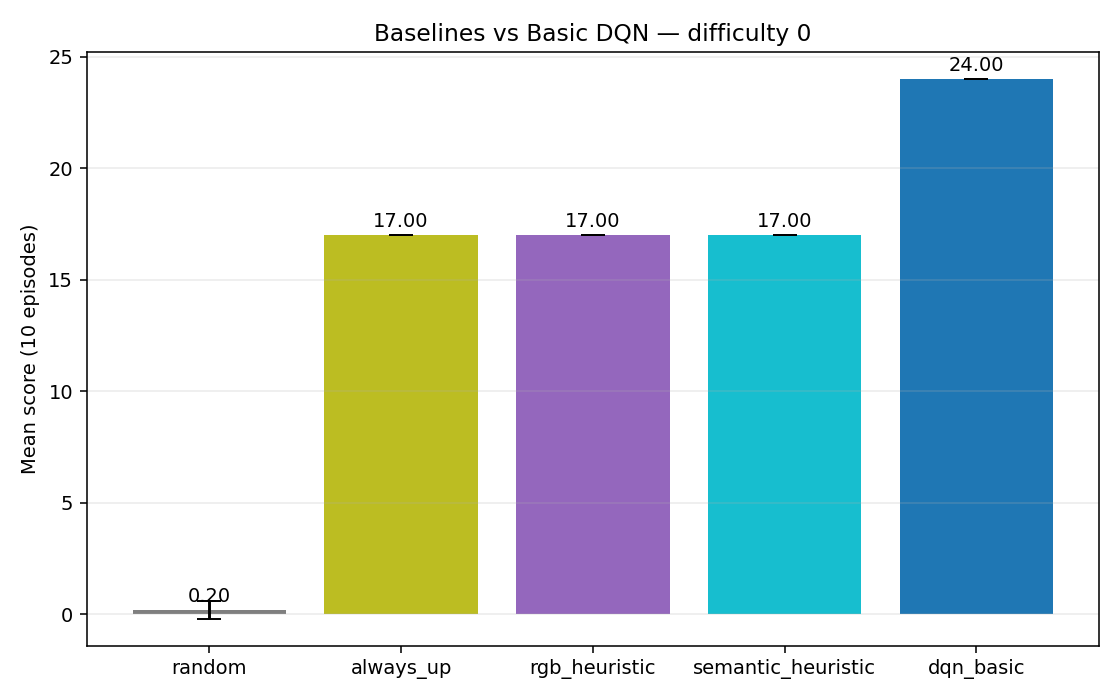

In [12]:
submission_dir = SUBMISSIONS_DIR / cfg.submission_name
submission_dir.mkdir(parents=True, exist_ok=True)
curves_path = plot_training(history, eval_history, submission_dir / 'training_curves.png')
bars_path = plot_baselines(baselines, final_eval, submission_dir / 'baselines_vs_dqn.png')
print(curves_path)
print(bars_path)

from IPython.display import Image, display
if curves_path is not None:
    display(Image(filename=str(curves_path)))
if bars_path is not None:
    display(Image(filename=str(bars_path)))

## Package the submission

In [13]:
if agent is not None:
    packager = SubmissionPackager(cfg)
    summary = packager.package(
        agent,
        state_shape=state_shape,
        history=history,
        eval_history=eval_history,
        baselines=baselines,
        final_eval=final_eval,
        train_minutes=train_minutes,
    )
    print('Packaged:', summary['files']['zip'])
else:
    print('Reusing existing submission at', submission_dir / f'submission_{cfg.submission_name}.zip')

Reusing existing submission at c:\Projects\DeepLearning\Assignment2\submissions\task1_basic_dqn\submission_task1_basic_dqn.zip


## Cross-difficulty evaluation

Re-evaluate the *exported* agent on every difficulty

In [14]:
agent_py = submission_dir / 'agent.py'
policy = DQNInferencePolicy(agent_py)
rows = []
for diff in (0, 1, 2, 3):
    entry = evaluator.run(policy, difficulty=diff, n_episodes=10,
                          include_semantic_info=False)
    rows.append({k: v for k, v in entry.items() if k != 'scores'})
    print(f'  diff={diff}: mean={entry["mean_score"]:.2f} std={entry["std_score"]:.2f}')
(DOCS_DIR / f'{cfg.submission_name}_difficulty_eval.json').write_text(
    json.dumps({'submission': cfg.submission_name, 'results': rows}, indent=2),
    encoding='utf-8')

print()
print(f"{'difficulty':>11}{'mean':>8}{'std':>8}{'min':>6}{'max':>6}")
for r in rows:
    print(f"{r['difficulty']:>11}{r['mean_score']:>8.2f}{r['std_score']:>8.2f}"
          f"{int(r['min_score']):>6}{int(r['max_score']):>6}")

  diff=0: mean=24.00 std=0.00
  diff=1: mean=21.00 std=0.00
  diff=2: mean=13.80 std=3.76
  diff=3: mean=11.90 std=1.97

 difficulty    mean     std   min   max
          0   24.00    0.00    24    24
          1   21.00    0.00    21    21
          2   13.80    3.76     9    21
          3   11.90    1.97     9    16


## GIF Display

In [15]:
if RECORD_GIF:
    recorder = GifRecorder(cfg)
    gif_path = recorder.record(policy, difficulty=0, seed=2026,
                                max_steps=200, scale=6, format='gif',
                                tag='dqn_overview')
    print(gif_path)
    from IPython.display import Image
    Image(filename=str(gif_path))
else:
    print('Skipped (RECORD_GIF=False).')

C:\Projects\DeepLearning\Assignment2\docs\recordings\dqn_overview_diff0_seed2026.gif


## Verify the submission ZIP loads in isolation

Extract the ZIP into a temp directory, instantiate `Agent`, run one episode.

In [16]:
import shutil, tempfile, zipfile
tmp = Path(tempfile.mkdtemp(prefix='spacerace_zip_'))
with zipfile.ZipFile(submission_dir / f'submission_{cfg.submission_name}.zip') as zf:
    zf.extractall(tmp)
tmp_policy = DQNInferencePolicy(tmp / 'agent.py')
result = evaluator.run(tmp_policy, n_episodes=3, include_semantic_info=False)
shutil.rmtree(tmp, ignore_errors=True)
print(f"isolated re-eval: mean={result['mean_score']:.2f} "
      f"std={result['std_score']:.2f} (3 episodes)")

isolated re-eval: mean=24.00 std=0.00 (3 episodes)
